In [1]:
#import libiraryes
import random

# Problem Data

In [2]:
# total electricity demand
demand = 150

# Generator 1 limit
p1_min = 20
p1_max = 100

#Generator 2 limit
p2_min = 30
p2_max = 120

# Cost Function

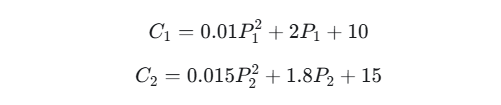

In [3]:
def calculate_cost(p1):
    # Calculate generator 2 output from total demand
    p2 = 150 - p1

    # Generator 1 operating cost
    c1 = 0.01 * p1**2 + 2 * p1 + 10
    
    # Generator 2 operating cost
    c2 = 0.015 * p2**2 + 1.8 * p2 + 15

    # Return total operatinr cost
    return c1+c2

In [4]:
print(calculate_cost(80)) # expected 448.5

448.5


# PSO Parameters

In [5]:
# Import the random module
# Define number of particles
number_of_particles = 40

# Define number of iterations
number_of_iterations = 200

# Define inertia weight (w)
w = 0.7

# Define cognitive coefficient (c1)
COGNITIVE= 1.5

# Define social coefficient (c2)
SOCIAL= 1.5


# Particle Class

In [6]:
# Define a class named Particle
class Particle:

    # Define the constructor (__init__)
    def __init__(self,position,velocity):
        # Receive initial position and initial velocity
        # Store the current position
        # Store the current velocity
        self.position = position
        self.velocity = velocity
        

        # Calculate the cost of the initial position
        initial_cost = calculate_cost(position)
        # Set the initial position as the personal best position
        self.personal_best_position = position
        # Set the initial cost as the personal best cost
        self.personal_best_cost = initial_cost 


# Swarm Initialization

In [7]:
# Valid P1 limits after considering both generator
valid_p1_min = max(p1_min,demand-p2_max)
valid_p1_max = min(p1_max,demand-p2_min)

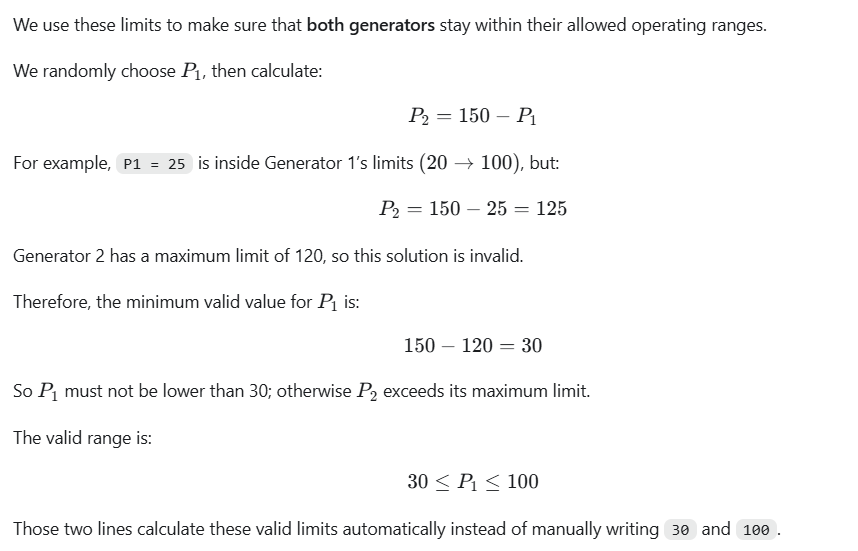

In [8]:
# Define a function named initialize_swarm
def initialize_swarm(number_of_particles):
    # Create an empty list named swarm
    swarm = []
    
    # Repeat for the required number of particles
    for i in range(number_of_particles):
        # Generate a random valid position for P1
        position = random.uniform(valid_p1_min,valid_p1_max)
        
        # Generate a random initial velocity
        velocity = random.uniform(-5,5)
        '''
            We use -5 to 5 as a small, balanced starting range. 
            It is not a fixed rule—you can tune it. 
            Since P1 ranges only from 30 to 100, 
            a very large initial velocity, such as -50 to 50, 
            would make particles jump too far and often hit 
            the boundaries.
        '''
        
        # Create a Particle object using this position and velocity
        paticle = Particle(position,velocity)
        
        # Add the Particle object to the swarm list
        swarm.append(paticle)
    # Return the swarm list
    return swarm


# Create the Initial Swarm

In [9]:
# Call initialize_swarm and save the returned list in swarm
swarm = initialize_swarm(number_of_particles)

In [10]:
for i,particle in enumerate (swarm, start=1):
    print(f"Particle {i}:position = {particle.position}")

Particle 1:position = 95.65091925337775
Particle 2:position = 92.73780616341449
Particle 3:position = 74.29304623120136
Particle 4:position = 92.83405811914447
Particle 5:position = 44.018425548885745
Particle 6:position = 37.867996226969225
Particle 7:position = 36.683392776964155
Particle 8:position = 50.7715033041661
Particle 9:position = 65.87705644992774
Particle 10:position = 74.04594459025355
Particle 11:position = 36.11784235773041
Particle 12:position = 83.9022575357875
Particle 13:position = 44.67004966780772
Particle 14:position = 51.973967293064206
Particle 15:position = 73.22296452588859
Particle 16:position = 66.53644485031805
Particle 17:position = 67.12844960538509
Particle 18:position = 65.39147155190258
Particle 19:position = 69.50864924082325
Particle 20:position = 54.790666458351936
Particle 21:position = 74.86895013719581
Particle 22:position = 77.6734999943248
Particle 23:position = 74.4447544245177
Particle 24:position = 98.2993713332609
Particle 25:position = 50

# Find the Initial Global Best

In [11]:
# Start with the first particle as the global best
global_best_postion = swarm[0].personal_best_position
global_best_cost = swarm[0].personal_best_cost

# Compare every particle with the current global best
for patricle in swarm :
    if patricle.personal_best_cost < global_best_cost :
        global_best_position = patricle.personal_best_position
        global_best_cost = particle.personal_best_cost
        

# PSO Main Loop

In [12]:
for interation in range(number_of_iterations):
    for particle in swarm:
        # Generate random value
        r1 = random.random()
        r2 = random.random()
        
        # Calculat velocity components
        inertia = w * particle.velocity

        cognitive = (COGNITIVE*r1*(particle.personal_best_position - particle.position))
        social = (SOCIAL*r2*(global_best_position - particle.position))

        # Update velocity
        particle.velocity = inertia + cognitive + social

        # Update posiion 
        particle.position = particle.position + particle.velocity

        # Keep position inside valid limits
        particle.position = max(valid_p1_min,
                                min(particle.position, valid_p1_max))
        
         # Calculate new cost
        current_cost = calculate_cost(particle.position)

        # Update personal best
        if current_cost < particle.personal_best_cost:
            particle.personal_best_position = particle.position
            particle.personal_best_cost = current_cost

        # Update global best
        if current_cost < global_best_cost:
            global_best_position = particle.position
            global_best_cost = current_cost

# Display Final Results

In [13]:
# Calculate final generator outputs
p1 = global_best_position
p2 = demand - p1

# Print final results
print(f"Generator 1 output: {p1:.2f} MW")
print(f"Generator 2 output: {p2:.2f} MW")
print(f"Minimum total cost: {global_best_cost:.2f}")

Generator 1 output: 86.00 MW
Generator 2 output: 64.00 MW
Minimum total cost: 447.60
